In [4]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
def func(x):
  return x**2 + 3*x + 1

In [9]:
xs = np.arange(-5, 5, 0.25)
xs

array([-5.  , -4.75, -4.5 , -4.25, -4.  , -3.75, -3.5 , -3.25, -3.  ,
       -2.75, -2.5 , -2.25, -2.  , -1.75, -1.5 , -1.25, -1.  , -0.75,
       -0.5 , -0.25,  0.  ,  0.25,  0.5 ,  0.75,  1.  ,  1.25,  1.5 ,
        1.75,  2.  ,  2.25,  2.5 ,  2.75,  3.  ,  3.25,  3.5 ,  3.75,
        4.  ,  4.25,  4.5 ,  4.75])

In [10]:
ys = func(xs)
ys

array([11.    ,  9.3125,  7.75  ,  6.3125,  5.    ,  3.8125,  2.75  ,
        1.8125,  1.    ,  0.3125, -0.25  , -0.6875, -1.    , -1.1875,
       -1.25  , -1.1875, -1.    , -0.6875, -0.25  ,  0.3125,  1.    ,
        1.8125,  2.75  ,  3.8125,  5.    ,  6.3125,  7.75  ,  9.3125,
       11.    , 12.8125, 14.75  , 16.8125, 19.    , 21.3125, 23.75  ,
       26.3125, 29.    , 31.8125, 34.75  , 37.8125])

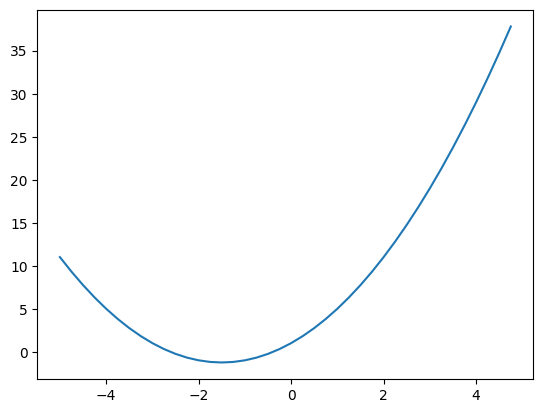

In [11]:
plt.plot(xs, ys)

In [14]:
x = 4.0
h = 0.00001
(func(x + h) - func(x)) / h

11.000009999406755

In [15]:
2 * x + 3

11.0

In [147]:
class Value:
  def __init__(self, data, _children = (), _op = '', _label=""):
    self.data = data
    self._prev = set(_children)
    self._op = _op
    self._label = _label
    self.grad = 0.0
    self._backward = lambda: None

  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self, other):
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad

    out._backward = _backward

    return out

  def __mul__(self, other):
    out = Value(self.data * other.data, (self, other), '*')

    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward

    return out

  def backward(self):
    topo = []
    visited = set()

    def build_topo(root):
      if root not in visited:
        visited.add(root)
        for node in root._prev:
            build_topo(node)
        topo.append(root)

    build_topo(self)
    self.grad = 1.0
    for node in reversed(topo):
      node._backward()

In [148]:
x = Value(2.0, _label = "x")
y = Value(3.0, _label = "y")
z = x*y; z._label = 'z'
w = z + y; w._label = 'w'

In [150]:
from graphviz import Digraph

In [151]:
def trace(root):
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
  nodes, edges = trace(root)

  for n in nodes:
    uid = str(id(n))

    dot.node(name = uid, label = f"{n._label} | {n.data:.4f} | {n.grad}" , shape='record')

    if n._op:
      dot.node(name = uid + n._op, label = n._op)
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot


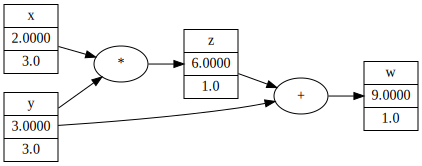

In [154]:
draw_dot(w)

In [153]:
w.backward()